İnitializations.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load Data

In [ ]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100.0%
100.0%
100.0%
100.0%


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

Baseline For our test and variants we will compare it to

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_loader), 100. * correct / total

In [ ]:
def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return test_loss / len(test_loader), 100. * correct / len(test_loader.dataset)

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

In [ ]:
for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

Epoch 1: Train Acc=91.47%, Test Acc=97.91%
Epoch 2: Train Acc=97.02%, Test Acc=98.76%
Epoch 3: Train Acc=97.98%, Test Acc=98.72%
Epoch 4: Train Acc=98.16%, Test Acc=98.86%
Epoch 5: Train Acc=98.55%, Test Acc=99.04%
Epoch 6: Train Acc=98.73%, Test Acc=99.10%
Epoch 7: Train Acc=98.84%, Test Acc=99.24%
Epoch 8: Train Acc=99.00%, Test Acc=99.34%
Epoch 9: Train Acc=99.12%, Test Acc=99.34%
Epoch 10: Train Acc=99.12%, Test Acc=99.32%


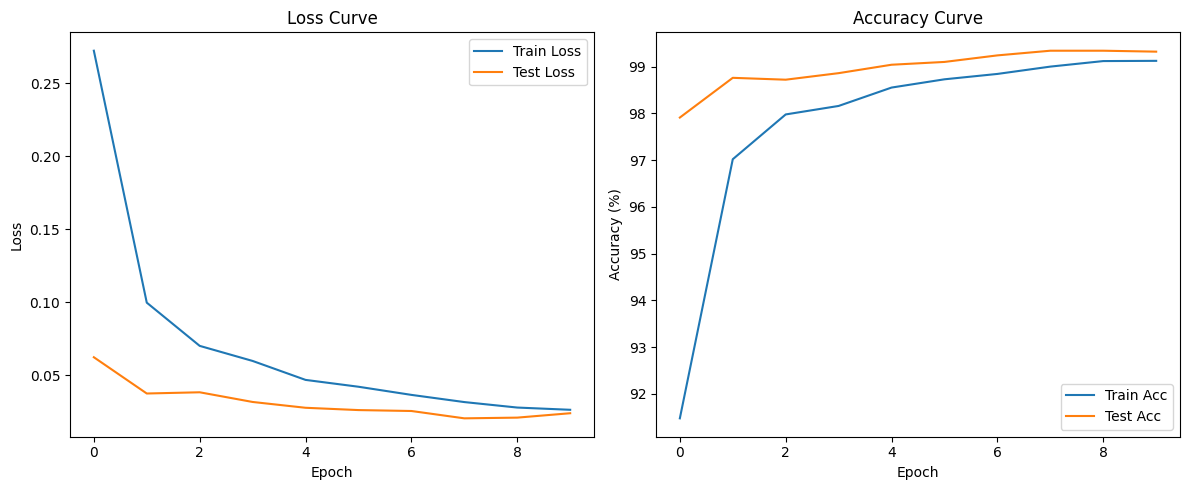

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Accuracy got pretty flat by the 4th epoch and losses stayed same after 4th epoch too.